In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [2]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sentiment_enc'] = le.fit_transform(df['sentiment'])
df = df.drop('sentiment', axis = 1)
print(df[['sentiment_enc']].head())

   sentiment_enc
0              1
1              1
2              1
3              0
4              1


In [3]:
import nltk
from nltk import word_tokenize, sent_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
tokenized_docs = [doc.lower().split() for doc in df['review']]

# Сбор всех слов
all_words = []
for doc in tokenized_docs:
    all_words.extend(doc)

# Создание словаря (ограничим первыми 10000 слов)
vocabulary = sorted(set(all_words))[:10000]
word_to_idx = {word: idx for idx, word in enumerate(vocabulary)}

print(f"Размер словаря: {len(vocabulary)}")
print(f"Пример слов: {list(vocabulary)[:20]}")

Размер словаря: 10000
Пример слов: ['\x08\x08\x08\x08a', '\x10own', '!', '!!', '!!!', '!!!!', '!!!!!', '!!!!!!', '!!!!!!!', '!!!!!!!!', '!!!!!!!!!', '!!!!!!!!!!', '!!!!!!!!!!!', '!!!!!!!!!!!!!', '!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!']


In [6]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Функция для токенизации и фильтрации
def tokenize_and_filter(text):
    tokens = text.split()
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)

# Применение фильтрации
df['review_tokens'] = df['review'].apply(tokenize_and_filter)

print("После фильтрации:")
print(df[['review', 'review_tokens']].head())

После фильтрации:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                       review_tokens  
0  One reviewers mentioned watching episode hooke...  
1  wonderful little production. <br /><br />The f...  
2  thought wonderful way spend time hot summer we...  
3  Basically there's family little boy (Jake) thi...  
4  Petter Mattei's "Love Time Money" visually stu...  


In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
le = LabelEncoder()
y = le.fit_transform(df['sentiment_enc'])

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    df['review_tokens'], 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Class distribution:\n{pd.Series(y_train).value_counts()}")

Train size: 40000
Test size: 10000
Class distribution:
1    20000
0    20000
Name: count, dtype: int64


In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
vectorizers = {
    '1_BoW_Unigram': CountVectorizer(max_features=5000, ngram_range=(1, 1)),
    '2_BoW_Bigram': CountVectorizer(max_features=5000, ngram_range=(2, 2)),
    '3_BoW_UniBi': CountVectorizer(max_features=5000, ngram_range=(1, 2)),
    '4_TFIDF_Unigram': TfidfVectorizer(max_features=5000, ngram_range=(1, 1)),
    '5_TFIDF_Bigram': TfidfVectorizer(max_features=5000, ngram_range=(2, 2)),
    '6_TFIDF_UniBi': TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    '7_TFIDF_Optimized': TfidfVectorizer(
        max_features=5000, 
        ngram_range=(1, 2),
        stop_words='english', 
        min_df=5, 
        max_df=0.7
    ),
    '8_Hashing': HashingVectorizer(n_features=5000, ngram_range=(1, 2))
}

In [9]:
X_vec_dict = {}

for vec_name, vectorizer in vectorizers.items():
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    X_vec_dict[vec_name] = (X_train_vec, X_test_vec)
    print(f"Размер: {X_train_vec.shape}")

Размер: (40000, 5000)
Размер: (40000, 5000)
Размер: (40000, 5000)
Размер: (40000, 5000)
Размер: (40000, 5000)
Размер: (40000, 5000)
Размер: (40000, 5000)
Размер: (40000, 5000)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
results_lr = []

for vec_name, (X_train_vec, X_test_vec) in X_vec_dict.items():
    print(f"Векторизатор: {vec_name}")

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_vec, y_train)
    

    y_pred = model.predict(X_test_vec)
 
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_vec, y_train, cv=3, scoring='accuracy')
    
    results_lr.append({
        'Vectorizer': vec_name,
        'Model': 'Logistic Regression',
        'Accuracy': accuracy,
        'F1_Score': f1,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std()
    })
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


df_lr = pd.DataFrame(results_lr)
print(df_lr[['Vectorizer', 'Accuracy', 'F1_Score']].to_string(index=False))

Векторизатор: 1_BoW_Unigram
  Accuracy: 0.8747
  F1 Score: 0.8748
  CV: 0.8619 (+/- 0.0015)
Векторизатор: 2_BoW_Bigram
  Accuracy: 0.8126
  F1 Score: 0.8146
  CV: 0.8036 (+/- 0.0012)
Векторизатор: 3_BoW_UniBi
  Accuracy: 0.8753
  F1 Score: 0.8748
  CV: 0.8638 (+/- 0.0019)
Векторизатор: 4_TFIDF_Unigram
  Accuracy: 0.8925
  F1 Score: 0.8934
  CV: 0.8841 (+/- 0.0020)
Векторизатор: 5_TFIDF_Bigram
  Accuracy: 0.8194
  F1 Score: 0.8219
  CV: 0.8172 (+/- 0.0018)
Векторизатор: 6_TFIDF_UniBi
  Accuracy: 0.8946
  F1 Score: 0.8955
  CV: 0.8865 (+/- 0.0022)
Векторизатор: 7_TFIDF_Optimized
  Accuracy: 0.8916
  F1 Score: 0.8925
  CV: 0.8816 (+/- 0.0010)
Векторизатор: 8_Hashing
  Accuracy: 0.8499
  F1 Score: 0.8510
  CV: 0.8370 (+/- 0.0044)
       Vectorizer  Accuracy  F1_Score
    1_BoW_Unigram    0.8747  0.874813
     2_BoW_Bigram    0.8126  0.814566
      3_BoW_UniBi    0.8753  0.874837
  4_TFIDF_Unigram    0.8925  0.893364
   5_TFIDF_Bigram    0.8194  0.821929
    6_TFIDF_UniBi    0.8946  0.89549

In [12]:
from sklearn.ensemble import RandomForestClassifier
results_rf = []

for vec_name, (X_train_vec, X_test_vec) in X_vec_dict.items():
    print(f"\nВекторизатор: {vec_name}")
    

    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_vec, y_train)
    
    y_pred = model.predict(X_test_vec)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_vec, y_train, cv=3, scoring='accuracy')
    
    results_rf.append({
        'Vectorizer': vec_name,
        'Model': 'Random Forest',
        'Accuracy': accuracy,
        'F1_Score': f1,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std()
    })
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

df_rf = pd.DataFrame(results_rf)
print(df_rf[['Vectorizer', 'Accuracy', 'F1_Score']].to_string(index=False))


Векторизатор: 1_BoW_Unigram
Accuracy: 0.8510
F1 Score: 0.8500
CV: 0.8437 (+/- 0.0030)

Векторизатор: 2_BoW_Bigram
Accuracy: 0.7825
F1 Score: 0.7747
CV: 0.7714 (+/- 0.0029)

Векторизатор: 3_BoW_UniBi
Accuracy: 0.8536
F1 Score: 0.8524
CV: 0.8450 (+/- 0.0024)

Векторизатор: 4_TFIDF_Unigram
Accuracy: 0.8528
F1 Score: 0.8509
CV: 0.8453 (+/- 0.0030)

Векторизатор: 5_TFIDF_Bigram
Accuracy: 0.7808
F1 Score: 0.7775
CV: 0.7743 (+/- 0.0029)

Векторизатор: 6_TFIDF_UniBi
Accuracy: 0.8545
F1 Score: 0.8531
CV: 0.8478 (+/- 0.0027)

Векторизатор: 7_TFIDF_Optimized
Accuracy: 0.8525
F1 Score: 0.8514
CV: 0.8436 (+/- 0.0020)

Векторизатор: 8_Hashing
Accuracy: 0.8128
F1 Score: 0.8096
CV: 0.8016 (+/- 0.0009)
       Vectorizer  Accuracy  F1_Score
    1_BoW_Unigram    0.8510  0.850010
     2_BoW_Bigram    0.7825  0.774728
      3_BoW_UniBi    0.8536  0.852449
  4_TFIDF_Unigram    0.8528  0.850922
   5_TFIDF_Bigram    0.7808  0.777507
    6_TFIDF_UniBi    0.8545  0.853104
7_TFIDF_Optimized    0.8525  0.851385


In [13]:

all_results = pd.concat([df_lr, df_rf], ignore_index=True)

print("Logistic Regression vs Random Forest")
print(all_results.to_string(index=False))


all_results.to_csv('lr_vs_rf_results.csv', index=False)

Logistic Regression vs Random Forest
       Vectorizer               Model  Accuracy  F1_Score  CV_Mean   CV_Std
    1_BoW_Unigram Logistic Regression    0.8747  0.874813 0.861875 0.001525
     2_BoW_Bigram Logistic Regression    0.8126  0.814566 0.803600 0.001203
      3_BoW_UniBi Logistic Regression    0.8753  0.874837 0.863850 0.001938
  4_TFIDF_Unigram Logistic Regression    0.8925  0.893364 0.884125 0.001972
   5_TFIDF_Bigram Logistic Regression    0.8194  0.821929 0.817225 0.001844
    6_TFIDF_UniBi Logistic Regression    0.8946  0.895499 0.886525 0.002218
7_TFIDF_Optimized Logistic Regression    0.8916  0.892503 0.881650 0.001014
        8_Hashing Logistic Regression    0.8499  0.850988 0.837050 0.004388
    1_BoW_Unigram       Random Forest    0.8510  0.850010 0.843700 0.003031
     2_BoW_Bigram       Random Forest    0.7825  0.774728 0.771400 0.002873
      3_BoW_UniBi       Random Forest    0.8536  0.852449 0.844950 0.002392
  4_TFIDF_Unigram       Random Forest    0.8528  0.

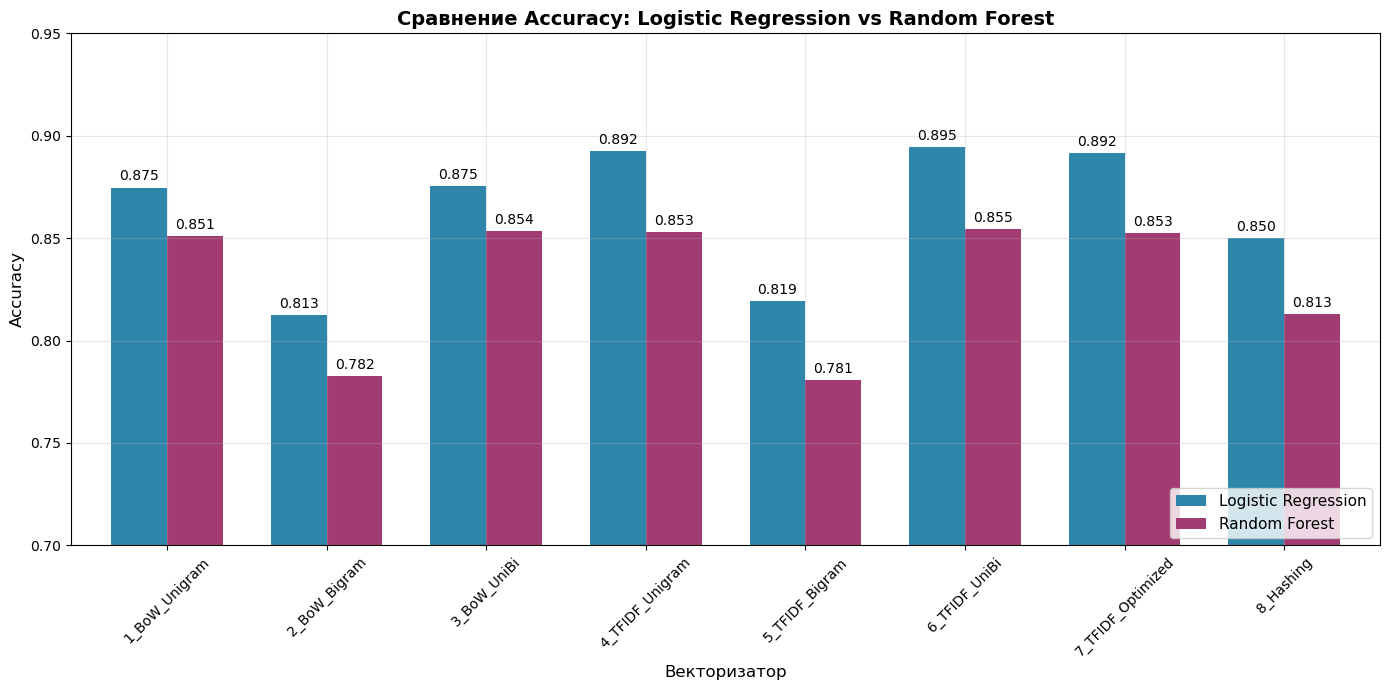

In [18]:

pivot_acc = all_results.pivot(index='Vectorizer', columns='Model', values='Accuracy')

fig, ax = plt.subplots(figsize=(14, 7))

pivot_acc.plot(kind='bar', ax=ax, color=['#2E86AB', '#A23B72'], width=0.7)

ax.set_title('Сравнение Accuracy: Logistic Regression vs Random Forest', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Векторизатор', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim([0.7, 0.95])

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10, padding=3)

plt.tight_layout()
plt.savefig('lr_vs_rf_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

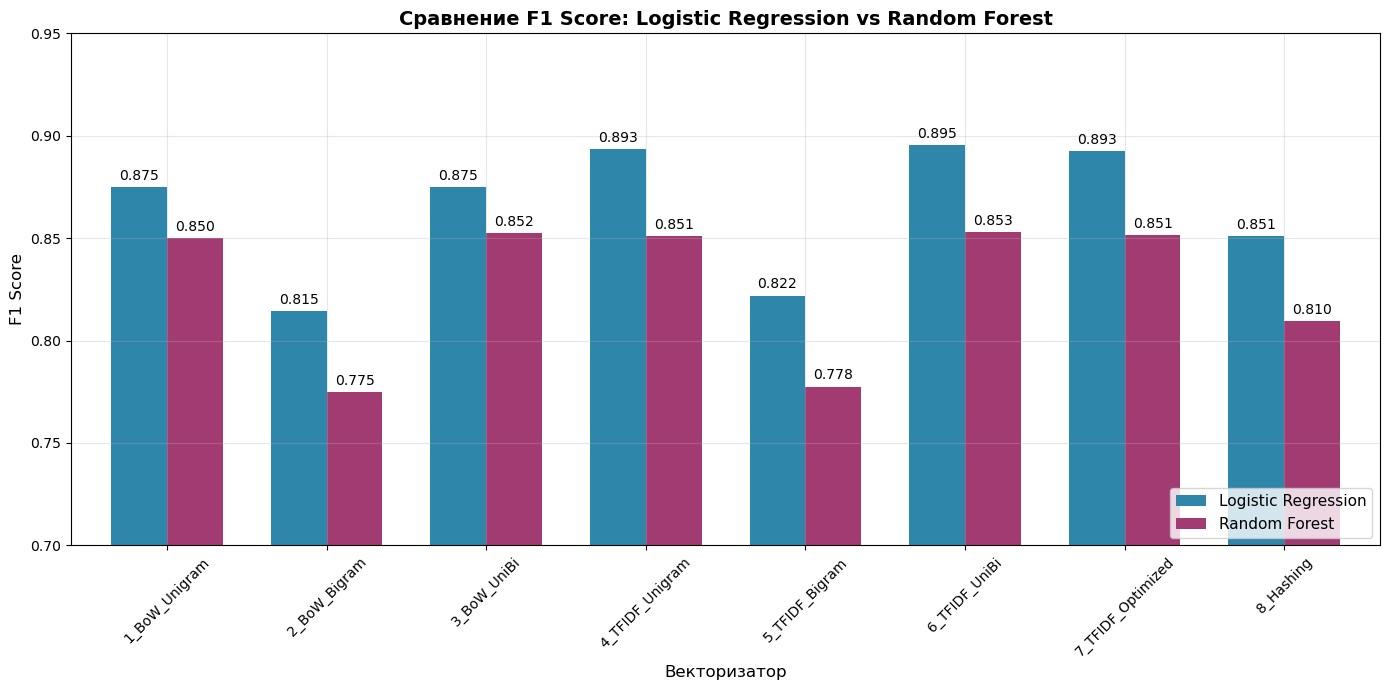

In [20]:

pivot_f1 = all_results.pivot(index='Vectorizer', columns='Model', values='F1_Score')

fig, ax = plt.subplots(figsize=(14, 7))

pivot_f1.plot(kind='bar', ax=ax, color=['#2E86AB', '#A23B72'], width=0.7)

ax.set_title('Сравнение F1 Score: Logistic Regression vs Random Forest', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Векторизатор', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim([0.7, 0.95])

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10, padding=3)

plt.tight_layout()
plt.savefig('lr_vs_rf_f1.png', dpi=150, bbox_inches='tight')
plt.show()

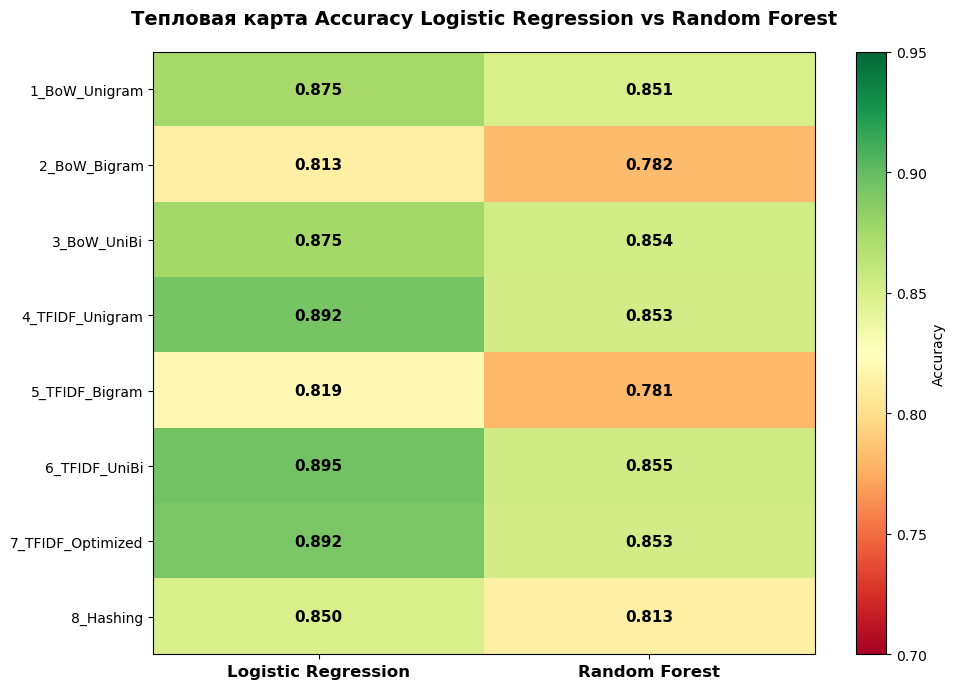

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

heatmap_data = all_results.pivot(index='Vectorizer', columns='Model', values='Accuracy')
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=0.95)

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns, fontsize=12, fontweight='bold')
ax.set_yticklabels(heatmap_data.index, fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        text = ax.text(j, i, f'{heatmap_data.values[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=11, fontweight='bold')

ax.set_title('Тепловая карта Accuracy Logistic Regression vs Random Forest', 
             fontsize=14, fontweight='bold', pad=20)
fig.colorbar(im, ax=ax, label='Accuracy')

plt.tight_layout()
plt.savefig('lr_vs_rf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()